In [ ]:
#@title Importamos las librerías necesarias.
# Import the necessary libraries.
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import os
import math
import statistics
import time
from difflib import SequenceMatcher
from collections import defaultdict
from google.colab import drive
from google.colab.patches import cv2_imshow


In [ ]:
!pip install ultralytics

import ultralytics
from ultralytics import YOLO
from ultralytics import RTDETR
from torchvision.ops import nms

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 891.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
#@title Configurando el Drive.
# Setting up Drive.
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Trabajo de Grado')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Trabajo de Grado


In [ ]:
#@title Definimos metodos importantes para procesar labels a texto

#Metodo para obtener las annotaciones en un mismo formato.
#Method to obtain all annotations in the same format.
def parse_annotation(annotation_text):
    labels = []

    for line in annotation_text.strip().split("\n"):
          polygon = []
          values = line.split()

          for n in values:
            polygon.append(float(n))
          labels.append(polygon)

    return labels

#Metodo para dibujar poligonos/bounding boxes en la imagen.
#Method to draw the polygons/bounding boxes in the image.
def draw_polygons(image, labels, color=(86,5,145)):
    labels_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z', 26: 'a_tilde', 27: 'ampersand', 28: 'apostrophe', 29: 'asterisk', 30: 'capital', 31: 'close_parenthesis', 32: 'closequotatioN', 33: 'colon', 34: 'comma', 35: 'e_tilde', 36: 'exclamation_mark', 37: 'greaterthan', 38: 'hyphen', 39: 'i_tilde', 40: 'lessthan', 41: 'letter_sign', 42: 'minus', 43: 'n_tilde', 44: 'number_sign', 45: 'o_tilde', 46: 'open_parenthesis', 47: 'parentheses', 48: 'period', 49: 'question_mark', 50: 'semicolon', 51: 'slash', 52: 'u_dieresis', 53: 'u_tilde'
    }

    img = image.copy()

    h, w = img.shape[:2]
    for n in labels:
      if len(n) == 5:
        id_class = int(n[0])
        x1 = int((n[1] - n[3]/2) * w)
        y1 = int((n[2] - n[4]/2) * h)

        x2 = int((n[1] + n[3]/2) * w)
        y2 = int((n[2] + n[4]/2) * h)

        cv2.rectangle(img,(x1, y1),(x2, y2),color,2)

        cv2.putText(img, str(labels_map[id_class]), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

      else:
        id_class = int(n[0])
        coords = np.array(n[1:], dtype=np.float32)

        coords[0::2] *= w  # x
        coords[1::2] *= h  # y

        pts = coords.reshape(-1, 2).astype(np.int32)

        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        cv2.putText(img, str(labels_map[id_class]), (pts[0,0], pts[0,1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    text = spatial_organization_txt(labels,h,w)

    return img, text

def spatial_organization_txt(labels,h,w):
    # Declaramos un diccionario para caracteres especiales
    labels_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z', 26: 'a_tilde', 27: 'ampersand', 28: 'apostrophe', 29: 'asterisk', 30: 'capital', 31: 'close_parenthesis', 32: 'closequotatioN', 33: 'colon', 34: 'comma', 35: 'e_tilde', 36: 'exclamation_mark', 37: 'greaterthan', 38: 'hyphen', 39: 'i_tilde', 40: 'lessthan', 41: 'letter_sign', 42: 'minus', 43: 'n_tilde', 44: 'number_sign', 45: 'o_tilde', 46: 'open_parenthesis', 47: 'parentheses', 48: 'period', 49: 'question_mark', 50: 'semicolon', 51: 'slash', 52: 'u_dieresis', 53: 'u_tilde'
    }
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }

    #Instanciamos listas para guardar lo que contienen los archivos de label
    classes = []
    bounding_boxes = []
    #Instanciamos una lista para guardar la altura de las bounding boxes
    y_difference = []
    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    #Revisamos que hayan bounding boxes que organizar
    lenght = len(labels)
    if lenght == 0:
      return []
    else:
      for n in labels:
        if len(n) == 5:
          #Extraemos lo que nos interesa de las labels
          id_class = int(n[0])
          x1 = int((n[1] - n[3]/2) * w)
          y1 = int((n[2] - n[4]/2) * h)
          x2 = int((n[1] + n[3]/2) * w)
          y2 = int((n[2] + n[4]/2) * h)

          classes.append(labels_map[id_class])
          bounding_boxes.append((x1, y1, x2, y2))
          y_difference.append(float(np.abs(y1-y2)))
        else:
          id_class = int(n[0])
          coords = np.array(n[1:], dtype=np.float32)

          coords[0::2] *= w  # x
          coords[1::2] *= h  # y

          pts = coords.reshape(-1, 2).astype(np.int32)
          y_max = np.max(pts[:,1])
          y_min = np.min(pts[:,1])

          classes.append(labels_map[id_class])
          bounding_boxes.append(pts)
          y_difference.append(float(np.abs(y_max-y_min)))

    #Sacamos un promedio de las alturas de todas las letras
    y_threshold = statistics.mean(y_difference)
    y_threshold = y_threshold * 0.9 # tolerancia vertical en píxeles

    #Ordenamos las cajas respecto a sus posiciones en X (De izquierda a derecha)
    ordered_boxes = sorted(zip(bounding_boxes,classes), key= lambda x: x[0][0] if isinstance(x[0], tuple) else x[0][0][0])
    bounding_boxes = [x for x,y in ordered_boxes]
    classes = [y for x,y in ordered_boxes]

    # Agrupar letras por líneas
    for i in range(len(bounding_boxes)):
        #Extraer los datos de todas las detecciones, clase como string, bounding box y la posición en Y centrada
        letra = classes[i].lower()
        current_box = bounding_boxes[i]
        if isinstance(current_box, tuple): # Caja de la forma (x1, y1, x2, y2)
            x1, y1, x2, y2 = current_box
        else: # Polygonal box (numpy array [[x_min,y_min], [x_max,y_max], ...])
            # Para poligonos, se calculan las esquinas para transformala en caja
            x1 = np.min(current_box[:, 0])
            y1 = np.min(current_box[:, 1])
            x2 = np.max(current_box[:, 0])
            y2 = np.max(current_box[:, 1])
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False

        #Iteramos por todas las bounding boxes mirando cuales están dentro de la tolerancia vertical de la primera, así separaos las lineas
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenamos las líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Instanciamos lista para el texto final
    texto_final = []
    for _, letras in sorted_lines:

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras
        # Se extraen las coordenadas en x
        x_coords = [x for x, _ in letras]
        # Se calculan las distancias
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # Tolerancia horizontal + 20% de error

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            # Se calcula la distancia
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold: #Si la distancia es mayor al umbral, se pone un espacio
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)


    return texto_final

In [ ]:
#@title Definimos metodos importantes para procesar resultados de Ultralytics

def nms_Yolo(results, image, iou=0.3):
    # Obtenemos las cajas, los puntajes y las clases.
    # Get the boxes, scores and classes.
    boxes = results[0].boxes.xyxy
    scores = results[0].boxes.conf
    classes = results[0].boxes.cls

    # Aplicar NMS manualmente con IoU
    # Apply NMS manually with IoU
    keep = nms(boxes, scores, iou_threshold=iou)

    # Filtrar resultados
    # Filter the results
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = classes[keep]

    image = results[0].orig_img.copy()

    # Usa las predicciones filtradas con NMS
    # Use filtered predictions with NMS
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        conf = float(filtered_scores[i])
        x1, y1, x2, y2 = map(int, filtered_boxes[i])
        label = f"{results[0].names[cls]}"

        # Dibujar rectángulo
        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)

        # Etiqueta con fondo
        # Label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1 - th - 4), (x1 + tw, y1), (0, 255, 255), -1)
        cv2.putText(image, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    text = spatial_organization(results, keep, filtered_boxes, filtered_classes)

    return image, text

def spatial_organization(results, keep, filtered_boxes, filtered_classes):
    # Declaramos un diccionario para caracteres especiales
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }
    #Instanciamos una lista para guardar la altura de las bounding boxes
    y_difference = []
    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    #Revisamos que hayan bounding boxes que organizar
    lenght = len(filtered_boxes)
    if lenght == 0:
      return []
    else:
      for n in range(len(keep)):
        y_difference.append(np.abs(filtered_boxes[n][1].item()-filtered_boxes[n][3].item()))

    #Sacamos un promedio de las alturas de todas las letras
    y_threshold = statistics.mean(y_difference)
    y_threshold = y_threshold * 0.9 # tolerancia vertical en píxeles

    #Ordenamos las cajas respecto a sus posiciones en X (De izquierda a derecha)
    ordered_boxes = sorted(zip(filtered_boxes,filtered_classes), key= lambda x: x[0][0])
    filtered_boxes = [x for x,y in ordered_boxes]
    filtered_classes = [y for x,y in ordered_boxes]

    # Agrupar letras por líneas
    for i in range(len(keep)):
        #Extraer los datos de todas las detecciones, clase como string, bounding box y la posición en Y centrada
        cls = int(filtered_classes[i])
        letra = results[0].names[cls].lower()
        x1, y1, x2, y2 = filtered_boxes[i].tolist()
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False

        #Iteramos por todas las bounding boxes mirando cuales están dentro de la tolerancia vertical de la primera, así separaos las lineas
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenamos las líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Instanciamos lista para el texto final
    texto_final = []
    for _, letras in sorted_lines:
        letras.sort(key=lambda x: x[0])  # ordenar letras por x

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras
        # Se extraen las coordenadas en x
        x_coords = [x for x, _ in letras]
        # Se calculan las distancias
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # Tolerancia horizontal + 20% de error

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            # Se calcula la distancia
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold: #Si la distancia es mayor al umbral, se pone un espacio
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)

    return texto_final

In [ ]:
test_path = "Dataset - Yolo/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
labels_txt = sorted(os.listdir(f'{test_path}/labels'))
text_path = "Dataset - Yolo/text"

# Create the directory if it does not exist
os.makedirs(text_path, exist_ok=True)

for indx in range(len(images_jpg)):
    image_sample = cv2.imread(os.path.join(test_path, "images", images_jpg[indx]), cv2.IMREAD_COLOR)
    label = open(os.path.join(test_path, "labels", labels_txt[indx]), "r").read()
    label = parse_annotation(label)
    label_sample = label

    img, text = draw_polygons(image_sample, label_sample)
    text_lines = '\n'.join(text)

    with open(os.path.join(text_path, f"{images_jpg[indx][:-4]}.txt"), "w") as f:
        f.write(text_lines)

In [ ]:
test_path = "Dataset - Yolo/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
text_path = "Dataset - Yolo/inference_Test/Yolo"

model_Yolo = YOLO('Dataset - Yolo/runs/detect/trainv8/weights/best.pt')

# Create the directory if it does not exist
os.makedirs(text_path, exist_ok=True)
print(os.getcwd())

for indx in range(len(images_jpg)):
    image_sample = os.path.join(os.getcwd(), test_path, "images", images_jpg[indx])
    results = model_Yolo.predict(source= image_sample, save=False, conf=0.25)
    nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)

    text_lines = '\n'.join(text_results)

    with open(os.path.join(text_path, f"{images_jpg[indx][:-4]}.txt"), "w") as f:
        f.write(text_lines)

/content/drive/MyDrive/Trabajo de Grado

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000034_jpg.rf.43268c405699054ee6a0b153f24845c5.jpg: 640x640 1 E, 1 L, 1 O, 1 V, 6.9ms
Speed: 1.2ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000042_jpg.rf.b6173b047fc015032446c84013591e31.jpg: 640x640 9 As, 5 Bs, 3 Cs, 4 Ds, 20 Es, 3 Fs, 1 G, 10 Hs, 10 Is, 2 Ks, 14 Ls, 3 Ms, 7 Ns, 6 Os, 3 Ps, 14 Rs, 4 Ss, 6 Ts, 1 U, 1 V, 4 Ys, 1 hyphen, 13.8ms
Speed: 1.0ms preprocess, 13.8ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000089_jpg.rf.58c404a31a2cd7c09ed5fc55d8fe80cd.jpg: 640x640 2 As, 1 C, 2 Es, 1 R, 1 T, 7.7ms
Speed: 0.9ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado

In [ ]:
test_path = "Dataset - Yolo/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
text_path = "Dataset - Yolo/inference_Test/RT-DETR"

model_trans = RTDETR('runs/detect/train_trans/weights/best.pt')

# Create the directory if it does not exist
os.makedirs(text_path, exist_ok=True)
print(os.getcwd())

for indx in range(len(images_jpg)):
    image_sample = os.path.join(os.getcwd(), test_path, "images", images_jpg[indx])
    results = model_trans.predict(source= image_sample, save=False, conf=0.25)
    nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)

    text_lines = '\n'.join(text_results)

    with open(os.path.join(text_path, f"{images_jpg[indx][:-4]}.txt"), "w") as f:
        f.write(text_lines)

/content/drive/MyDrive/Trabajo de Grado

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000034_jpg.rf.43268c405699054ee6a0b153f24845c5.jpg: 640x640 1 E, 1 L, 1 O, 1 V, 39.5ms
Speed: 1.2ms preprocess, 39.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000042_jpg.rf.b6173b047fc015032446c84013591e31.jpg: 640x640 9 As, 5 Bs, 2 Cs, 4 Ds, 14 Es, 3 Fs, 1 G, 10 Hs, 8 Is, 1 K, 11 Ls, 3 Ms, 6 Ns, 8 Os, 2 Ps, 9 Rs, 4 Ss, 10 Ts, 1 U, 1 V, 4 Ws, 5 Ys, 1 hyphen, 39.6ms
Speed: 0.8ms preprocess, 39.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/0000089_jpg.rf.58c404a31a2cd7c09ed5fc55d8fe80cd.jpg: 640x640 1 A, 1 C, 2 Es, 1 R, 1 T, 39.1ms
Speed: 0.8ms preprocess, 39.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Trabajo d

In [ ]:
import google.generativeai as genai
from PIL import Image
import os
import matplotlib.pyplot as plt
import time

# Configuramos la API KEY de Google AI Studio
genai.configure(api_key="Gemini_Api_Key")

# Carga tu imagen
test_path = "Dataset - Yolo/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
text_path = "Dataset - Yolo/inference_Test/Gemini"

# Crear el directorio si no existe
os.makedirs(text_path, exist_ok=True)
print(os.getcwd())

translation_time = []
api_call_counter = 0
requests_per_minute_limit = 12

model_instance = genai.GenerativeModel(model_name='models/gemini-3.5-flash-lite')

for indx in range(len(images_jpg)):
    image_path = os.path.join(os.getcwd(), test_path, "images", images_jpg[indx])
    image = Image.open(image_path)

    start = time.time()
    # Uso del modelo gemini 3.5 flash lite
    response = model_instance.generate_content(
        contents=["Traduce lo que dice la imagen en braille a texto (No uses los simbolos de braille, usa el lenguaje natural) usando saltos de linea cuando sean necesarios, porfavor sólo produce el texto sin mensajes extras.", image]
    )
    translation_time.append(time.time()-start)

    with open(os.path.join(text_path, f"{images_jpg[indx][:-4]}.txt"), "w") as f:
        f.write(response.text)

    api_call_counter += 1

    if api_call_counter % requests_per_minute_limit == 0 and (indx < len(images_jpg) - 1):
        time.sleep(90) # Espera para no superar el limite impuesto por google ai studio

avg_time = sum(translation_time) / len(translation_time)
print("Average time per image:", avg_time)

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


/content/drive/MyDrive/Trabajo de Grado


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 43515.70ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-3.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 37405.15ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-3.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 45901.67ms


Average time per image: 4.3027344912290575


In [ ]:
#@title Implementamos una forma de medir la similitud de las palabras
def word_accuracy(textA, textB):

  linesA = textA.splitlines()
  linesB = textB.splitlines()

  accuracy_per_line =[]
  max_lineas = max(len(linesA), len(linesB))
  if max_lineas == 0:
      return 1.0

  for i in range(max_lineas):
    l1 = linesA[i] if i < len(linesA) else ""
    l2 = linesB[i] if i < len(linesB) else ""

    text_match = SequenceMatcher(None, l1, l2).ratio()
    accuracy_per_line.append(text_match)

  accuracy = sum(accuracy_per_line) / len(accuracy_per_line)

  return accuracy

text_path = "Dataset - Yolo/text"
yolo_Text_path = "Dataset - Yolo/inference_Test/Yolo"
trans_Text_path = "Dataset - Yolo/inference_Test/RT-DETR"
gemini_Text_path = "Dataset - Yolo/inference_Test/Gemini"

ground_truth_text = sorted(os.listdir(text_path))
yolo_text = sorted(os.listdir(yolo_Text_path))
trans_text = sorted(os.listdir(trans_Text_path))
gemini_text = sorted(os.listdir(gemini_Text_path))

accuracy_yolo = []
accuracy_trans = []
accuracy_gemini = []

for indx in range(len(ground_truth_text)):
  with open(os.path.join(text_path, ground_truth_text[indx]), "r") as f:
    text_ground_truth = f.read()
  with open(os.path.join(yolo_Text_path, yolo_text[indx]), "r") as f:
    text_yolo = f.read()
  with open(os.path.join(trans_Text_path, trans_text[indx]), "r") as f:
    text_trans = f.read()
  with open(os.path.join(gemini_Text_path, gemini_text[indx]), "r") as f:
    text_gemini = f.read()

  indx_yolo_accuracy =  word_accuracy(text_ground_truth, text_yolo)
  indx_trans_accuracy =  word_accuracy(text_ground_truth, text_trans)
  indx_gemini_accuracy =  word_accuracy(text_ground_truth, text_gemini)

  accuracy_yolo.append(indx_yolo_accuracy)
  accuracy_trans.append(indx_trans_accuracy)
  accuracy_gemini.append(indx_gemini_accuracy)

accuracy_yolo_total = sum(accuracy_yolo) / len(accuracy_yolo)
accuracy_trans_total = sum(accuracy_trans) / len(accuracy_trans)
accuracy_gemini_total = sum(accuracy_gemini) / len(accuracy_gemini)

print("---------------------Word Accuracy--------------------------")
print("Accuracy Yolo:", accuracy_yolo_total)
print("Accuracy RT-DETR:", accuracy_trans_total)
print("Accuracy Gemini:", accuracy_gemini_total)
print("------------------------------------------------------------")

---------------------Word Accuracy--------------------------
Accuracy Yolo: 0.7872392651210797
Accuracy RT-DETR: 0.7365495534264387
Accuracy Gemini: 0.10770012083512047
------------------------------------------------------------


3511_jpg.rf.61e97b0855ccfb7659d8d510f3760f3e.jpg


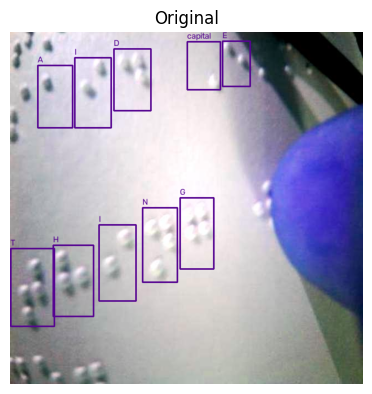

--------------------------------------------
Ground Truth:		Gemini:		YOLOv8
aid E thing			los libros en braille son importantes para la lectura			said E thing
--------------------------------------------


In [ ]:
test_path = "Dataset - Yolo/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
labels_txt = sorted(os.listdir(f'{test_path}/labels'))
gemini_text_path = "Dataset - Yolo/inference_Test/Gemini"
text_gemini = sorted(os.listdir(gemini_text_path))
yolo_text_path = "Dataset - Yolo/inference_Test/Yolo"
text_yolo = sorted(os.listdir(yolo_text_path))
ground_truth_text_path = "Dataset - Yolo/text"
ground_truth_text = sorted(os.listdir(ground_truth_text_path))

indx = random.choice(range(len(images_jpg)))

image_sample = cv2.imread(os.path.join(test_path, "images", images_jpg[indx]), cv2.IMREAD_COLOR)
label = open(os.path.join(test_path, "labels", labels_txt[indx]), "r").read()
label = parse_annotation(label)
label_sample = label
gemini_label = open(os.path.join(gemini_text_path, text_gemini[indx]), "r").read()
yolo_label = open(os.path.join(yolo_text_path, text_yolo[indx]), "r").read()
ground_truth_label = open(os.path.join(ground_truth_text_path, ground_truth_text[indx]), "r").read()

img, text = draw_polygons(image_sample, label_sample)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis('off')
plt.show()

print("--------------------------------------------")
print("Ground Truth:\t\tGemini:\t\tYOLOv8")
print(f"{ground_truth_label.replace('\n', ' ')}\t\t\t{gemini_label.replace('\n', ' ')}\t\t\t{yolo_label.replace('\n', ' ')}")
print("--------------------------------------------")